In [1]:
using Revise
using Printf
using LinearAlgebra
using PyPlot
#using FFTW
using MultiModeNoise

# Setup

In [2]:
# Here we define the necessary parameters for the simulation
# Wavelength [m]
λ0 = 1550e-9 
# Number of modes
M = 3 
# Incoming power [W]
P = 1e4 
# Excess noise from a single noisy source (i.e., a single laser coupled into a multimode fiber (MMF))
δF_in = 999; 

In [3]:
# Put the simulation parameters and derived quantities into a dictionary to pass to other functions
sim = MultiModeNoise.get_cw_sim_params(λ0, M, P, δF_in);

In [4]:
# Here we define the parameters of the graded index (GRIN) fiber we are considering in this example (Thorlabs GIF625)
# Length of the fiber [m]
L_fiber = 5 
# Radius of the fiber [μm]
radius = 62.5/2 
# Numerical aperture of the fiber's core
core_NA = 0.275 
# Shape parameter of the GRIN fiber
alpha = 2.08 
# Number of gridpoints in x & y to compute the fiber parameters and 
nx = 200 
# Name and directory of a file in which to store the fiber parameters once computed or from which to load if they have beeen computed already
fiber_fname = @sprintf("../fibers/CWFiber_GRIN_r=%.2f_M=%d_λ0=%.2fum_nx=%d.npz", radius, M, 1e6*λ0, nx) 

"../fibers/CWFiber_GRIN_r=31.25_M=3_λ0=1.55um_nx=200.npz"

In [5]:
# Here we compute/load the fiber properties (longitudinal phase evolution and nonlinear coupling) from the fiber parameters 
# and store them in a dictionary to pass to other functions
fiber = MultiModeNoise.get_cw_fiber_params(L_fiber, radius, core_NA, alpha, nx, sim, fiber_fname);

Load fiber params


In [6]:
# Here we set a fiber parameter that defines at which z-values functions return the field ampltidues and Bogoliubov coefficents
fiber["zsave"] = LinRange(0, L_fiber, 101);

In [7]:
# Define the inital conditions of the modal amplitudes that are sent into the fiber (Randomly chosen here)
u0 = √P*normalize([0.4, 0.1, 0.0]) .+ 0im
println(abs2.(u0)/P)

[0.9411764705882353, 0.058823529411764705, 0.0]


# Solve for field and Bogoliubov coefficients

In [8]:
# Solve the z-evolution of the modal ampltitudes (u) and Bogoliobov oefficients (μ, ν) and store the result in a dictionary
sol = MultiModeNoise.solve_cw_mmf(u0, fiber, sim);

In [9]:
# Extract the modal ampltiudes and Bogoliobov oefficients at output of the fiber from the solution dictionary
uf = sol["uz"][end,:]
μf = sol["μz"][end,:,:]
νf = sol["νz"][end,:,:];

In [10]:
# Compute the spatially resolved intensity and intensity noise at the output of the fiber by implementing the formulas from 
# section II.D. if the supplementary material. Here, we assume that we have one single source with excess noise (δF_in) that is split among
# the various fiber modes.
n, var_n = MultiModeNoise.compute_cw_spatial_n_var_n(u0, uf, μf, νf, δF_in, fiber["phi"], P);

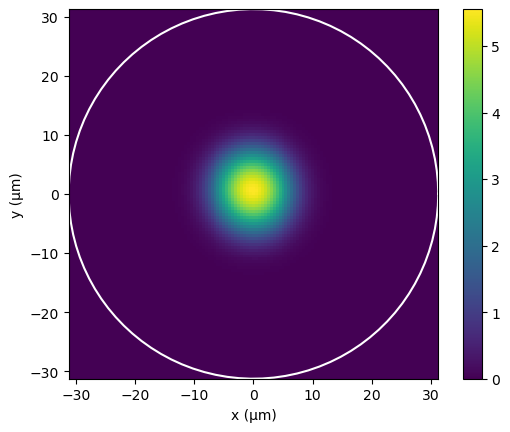

PyObject Text(24.000000000000007, 0.5, 'y (μm)')

In [11]:
# Plot the spatially resolved output Fano factor. MultiModeNoise.compute_cw_spatial_n_var_n returns the the output as a flattened vector.
MultiModeNoise.plot_fiber(fiber["x"], MultiModeNoise.lin_to_dB.(reshape(var_n ./ n, (nx,nx))), radius, radius)

In [12]:
# Compute the intensity and intensity noise of each fiber mode. Assumptions about the input noise are the same as in the above cell.
nf, var_n = MultiModeNoise.compute_cw_modal_n_var_n(u0, uf, μf, νf, δF_in, P)
MultiModeNoise.lin_to_dB.( var_n ./ nf)

3-element Vector{Float64}:
 29.738395265744195
 17.74904226069055
  1.9693246904226782

# Minimize Fano factor at a particular pixel / combination of pixels
In this section of the notebook, we find an input configuration for which the output Fano factor at a particular pixel or collection of pixels is minimized. We use gradient-based optimization for which we need a derivative of the output Fano factor in a particular mode w.r.t. the input of the optimizer. We compute this gradient by using forward-over-reverse differentiation to efficiently compute the necessary second derivatives. See Ch. 8.4.1 in https://arxiv.org/abs/2501.14787 <br>
This section contains all functions to recreate Fig. 2b,d of the main manuscript.

In [21]:
"""
    calc_output_reim(u0_reim, fiber, sim)

Helper function to compute the output u, μ, ν for an input given as real and imaginary parts of u

# Arguments
- `u0_reim`: Input modal amplitudes as [Re u, Im u]
- `fiber`: Fiber parameter dictionary
- `sim`: Simulation parameter dictionary
"""
function calc_output_reim(u0_reim, fiber, sim)
    fiber["zsave"] = [0, fiber["L"]]
    M = sim["M"]
    u0 = u0_reim[1:M] + 1im*u0_reim[M+1:2*M]
    sol = MultiModeNoise.solve_cw_mmf(u0, fiber, sim)

    uf = sol["uz"][end,:]
    μf = sol["μz"][end,:,:]
    νf = sol["νz"][end,:,:]

    return uf, μf, νf
end

"""
    calc_F∇F_dB!(Objective, Grad, x, p)

Computes for a particular pixel or collection of pixels the Fano factor (which is the cost function of the optimization) and gradient of 
the Fano factor w.r.t to the optimization variables. Computation of the cost and its gradient is wrapped in one function so calculations 
that are necessary for both are only performed once for effiency. 

# Arguments
- `Objective`: Input modal amplitudes as [Re u, Im u]
- `Grad`: Vector into which to write the gradient of the cost
- `x`: Optimization variables
- `p`: Parameters of the optimization procedure
"""
function calc_F∇F_dB!(Objective, Grad, x, p)
    pixel_indices, fiber, sim = p
    M = sim["M"]
    P = sim["P"]
    δF_in = sim["dF_in"]
    ϕ = fiber["phi"]
    ϕ_pixels = ϕ[pixel_indices,:]
    
    A = [[diagm(ones(M)) 1im*diagm(ones(M))]; [-1im*diagm(ones(M)) diagm(ones(M))]] / sqrt(P)

    u0_reim_norm = normalize(x)
    u0_reim = √P*u0_reim_norm
    u0 = u0_reim[1:M] + 1im*u0_reim[M+1:2*M]
    Uk = u0/√P
    Ũk = [Uk; -1im*Uk]

    ∂a∂x = sqrt(P)/norm(x)*(diagm(ones(length(x))) - x*x'/norm(x)^2)

    uf_reim, ∇n = MultiModeNoise.solve_∇n_pixels_cw_mmf_adjoint_reim(u0_reim, p; return_u=true)
    uf = uf_reim[1:M] + 1im*uf_reim[M+1:2*M]
    αi = ϕ_pixels * uf
    n = real(αi' * αi)
    
    no_derivative_term = real( αi' * αi - sum(abs2.(ϕ_pixels' * αi)) )
    shot_noise = ∇n' * ∇n / 4
    excess_noise = δF_in * abs2.(∇n' * A * u0_reim) / 4
    var_n = no_derivative_term + shot_noise + excess_noise
    
    F = var_n / n

    if Grad !== nothing
        B = ϕ_pixels' * ϕ_pixels * ϕ_pixels' * ϕ_pixels
        ∇g = 0.5*∇n + 0.5*δF_in*real.( (∇n' * conj.(Ũk)) * Ũk )
        ∇_var_n = ForwardDiff.derivative(α -> MultiModeNoise.solve_∇n_pixels_cw_mmf_adjoint_reim(u0_reim + α*∇g, p; return_u=false), 0)
        ∇_var_n += 0.5*δF_in*real.((∇n' * A * u0_reim) * A * ∇n)

        uf, μf, νf = calc_output_reim(u0_reim, fiber, sim)
        ∂udBu∂u = νf' * B * uf + transpose(uf' * B * μf)
        ∇_no_derivative_term = ∇n - real.([∂udBu∂u + conj.(∂udBu∂u); 1im*(∂udBu∂u - conj.(∂udBu∂u))])
        ∇_var_n += ∇_no_derivative_term 
        
        ∇F = ∇_var_n/n - var_n/n^2*∇n
        ∇F = ∂a∂x' * ∇F
        Grad .= 10/log(10) * ∇F / F
    end
    if Objective !== nothing
        return MultiModeNoise.lin_to_dB(F)
    end
end

"""
    callback_dB(state)

Callback function to monitor the progress of the optimization procedure.

# Arguments
- `state`: Current state of the optimization
"""
function callback_dB(state)
    if mod(state.iteration, 1) == 0
        println(@sprintf("Iteration: %d: F = %.6f dB, |g(x)| = %.8f", state.iteration, state.value, state.g_norm)); flush(stdout)
    end
    return false  # Return `true` to stop optimization early
end

callback_dB

In [22]:
using OptimizationOptimJL
using ForwardDiff
using Random

In [23]:
# Compute the grid of coordinates of the pixels
x = fiber["x"]
XX, YY = MultiModeNoise.meshgrid(x, x);

In [24]:
# Our optimization goal is to minimize th Fano factor in a 3x3 superpixel
superpixel_size = 3;

In [25]:
# Compute the indices (of the flattened array) of the pixels in the 3x3 superpixel.
idx = rand(MersenneTwister(1), (1:nx^2)[vec(XX).^2 + vec(YY).^2 .<= 10^2])
pixels = MultiModeNoise.get_center_square_pixels(nx, superpixel_size, [argmin((x .- vec(XX)[idx]).^2), argmin((x .- vec(YY)[idx]).^2)])
pixel_indices = MultiModeNoise.get_center_square_ids_flat(XX, YY, pixels);

In [26]:
# Optimization parameters
p_opt = (pixel_indices, fiber, sim);

In [27]:
# Random guess for the initial optimziation vector. Note that it is the unnormalized real and imaginary parts of the input modal amplitude.
x0 = 20*rand(MersenneTwister(3), 2*M) .- 10
# Turn the initial optimziation vector into input modal amplitudes.
u0_x0_reim = √P*normalize(x0)
u0_x0 = u0_x0_reim[1:M] + 1im*u0_x0_reim[M+1:2*M];

In [28]:
# Compute the output u, μ, ν from the inital optimization vector
uf_x0, μf_x0, νf_x0 = calc_output_reim(u0_x0_reim, fiber, sim);

In [29]:
# Use the above u, μ, ν to compute the intensity and intensity noise at the superpixel (which serves as the cost function for the 
# optimization)
n_x0, var_n_x0 = MultiModeNoise.compute_cw_superpixel_n_var_n(u0_x0, uf_x0, μf_x0, νf_x0, pixel_indices, δF_in, fiber["phi"], P);

In [30]:
MultiModeNoise.lin_to_dB(var_n_x0 / n_x0)

27.030640254082638

In [31]:
# Perform the optimization with the goal of decreasing the Fano factor in "opt_mode". Number of iterations capped at 10 for fast optimization
res = optimize(Optim.only_fg!((Objective, Grad, x) -> calc_F∇F_dB!(Objective, Grad, x, p_opt)), x0, LBFGS(), 
        Optim.Options(f_abstol=1e-5, iterations=10, callback=callback_dB))

Iteration: 0: F = 27.034914 dB, |g(x)| = 0.84786433
Iteration: 1: F = 9.823251 dB, |g(x)| = 51.52209603
Iteration: 2: F = 4.221600 dB, |g(x)| = 96.48633494
Iteration: 3: F = 0.866915 dB, |g(x)| = 61.41524099
Iteration: 4: F = 0.292077 dB, |g(x)| = 3.10346164
Iteration: 5: F = 0.290807 dB, |g(x)| = 0.42392454
Iteration: 6: F = 0.290542 dB, |g(x)| = 0.91008008
Iteration: 7: F = 0.288931 dB, |g(x)| = 5.16796048
Iteration: 8: F = 0.213923 dB, |g(x)| = 16.84180249
Iteration: 9: F = 0.072442 dB, |g(x)| = 14.34517396
Iteration: 10: F = 0.060862 dB, |g(x)| = 1.01865146


 * Status: failure (reached maximum number of iterations)

 * Candidate solution
    Final objective value:     6.086175e-02

 * Found with
    Algorithm:     L-BFGS

 * Convergence measures
    |x - x'|               = 7.19e-04 ≰ 0.0e+00
    |x - x'|/|x'|          = 7.22e-05 ≰ 0.0e+00
    |f(x) - f(x')|         = 1.16e-02 ≰ 1.0e-05
    |f(x) - f(x')|/|f(x')| = 1.90e-01 ≰ 0.0e+00
    |g(x)|                 = 1.02e+00 ≰ 1.0e-08

 * Work counters
    Seconds run:   12  (vs limit Inf)
    Iterations:    10
    f(x) calls:    35
    ∇f(x) calls:   35


In [32]:
# Compute the output u, μ, ν from the final optimization vector
u0_x_reim = √P*normalize(res.minimizer)
u0_x = u0_x_reim[1:M] + 1im*u0_x_reim[M+1:2*M]
uf_x, μf_x, νf_x = calc_output_reim(u0_x_reim, fiber, sim);
n_x, var_n_x = MultiModeNoise.compute_cw_superpixel_n_var_n(u0_x, uf_x, μf_x, νf_x, pixel_indices, δF_in, fiber["phi"], P);

In [33]:
MultiModeNoise.lin_to_dB(var_n_x / n_x)

0.06129335698471683

In [34]:
# Compute the spatially resolved intensity and intensity noise for the initial and final optimization vectors
n_x0, var_n_x0 = MultiModeNoise.compute_cw_spatial_n_var_n(u0_x0, uf_x0, μf_x0, νf_x0, δF_in, fiber["phi"], P);
n_x, var_n_x = MultiModeNoise.compute_cw_spatial_n_var_n(u0_x, uf_x, μf_x, νf_x, δF_in, fiber["phi"], P);

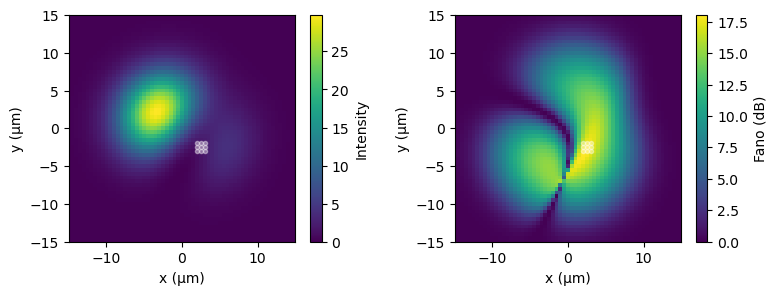

In [35]:
# Plot the spatially resolved intensity and intensity noise for the initial optimization vectors
# The pixels for which we want to minimize the Fano factor are marked by white circles
figure(figsize=(8,3))
subplot(121)
MultiModeNoise.plot_fiber(fiber["x"], reshape(n_x0, (nx,nx)), 15, radius; cbarlabel="Intensity")
plot(vec(XX)[pixel_indices], vec(YY)[pixel_indices], "w.", alpha=0.4)
subplot(122)
MultiModeNoise.plot_fiber(fiber["x"], MultiModeNoise.lin_to_dB.(reshape(var_n_x0 ./ n_x0, (nx,nx))), 15, radius; cbarlabel="Fano (dB)")
plot(vec(XX)[pixel_indices], vec(YY)[pixel_indices], "w.", alpha=0.4)
tight_layout()

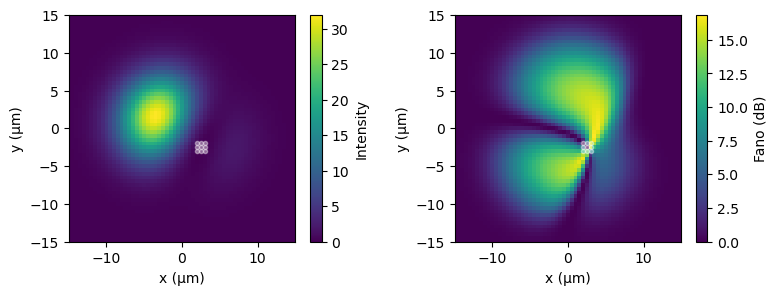

In [36]:
# Plot the spatially resolved intensity and intensity noise for the final optimization vectors
# The pixels for which we want to minimize the Fano factor are marked by white circles
figure(figsize=(8,3))
subplot(121)
MultiModeNoise.plot_fiber(fiber["x"], reshape(n_x, (nx,nx)), 15, radius; cbarlabel="Intensity")
plot(vec(XX)[pixel_indices], vec(YY)[pixel_indices], "w.", alpha=0.4)
subplot(122)
MultiModeNoise.plot_fiber(fiber["x"], MultiModeNoise.lin_to_dB.(reshape(var_n_x ./ n_x, (nx,nx))), 15, radius; cbarlabel="Fano (dB)")
plot(vec(XX)[pixel_indices], vec(YY)[pixel_indices], "w.", alpha=0.4)
tight_layout()

In [37]:
function compute_var_n_LA(n_out, P, F_in)
    l = n_out / P
    return l^2 * P * F_in + l * (1 - l) * P
end

function compute_var_n_rel_LA(n, var_n, noise_floor, P, F_in)
    var_n_LA = compute_var_n_LA(n, P, F_in)
    return (noise_floor + var_n) / (noise_floor + var_n_LA)
end

compute_var_n_rel_LA (generic function with 1 method)

In [38]:
using PyCall
@pyimport matplotlib.colors as mplcolors

In [39]:
noise_floor = 0.1;

In [40]:
# Compute the output intensity noise relative to the intensity noise found by linear attenuation of the initial beam to the observed power 
# levels for the initial and final optimization vectors
var_n_x0_rel_LA = compute_var_n_rel_LA.(n_x0, var_n_x0, noise_floor, P, 1 + δF_in)[:,1];
var_n_x_rel_LA = compute_var_n_rel_LA.(n_x, var_n_x, noise_floor, P, 1 + δF_in)[:,1];

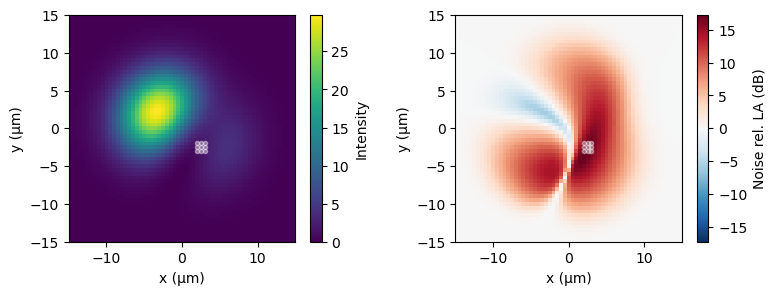

In [41]:
# Plot the output intensity noise relative to the intensity noise found by linear attenuation of the initial beam to the observed power 
# levels for the initial optimization vectors
figure(figsize=(8,3))
subplot(121)
MultiModeNoise.plot_fiber(fiber["x"], reshape(n_x0, (nx,nx)), 15, radius; cbarlabel="Intensity")
plot(vec(XX)[pixel_indices], vec(YY)[pixel_indices], "w.", alpha=0.4)
subplot(122)
MultiModeNoise.plot_fiber(fiber["x"], MultiModeNoise.lin_to_dB.(reshape(var_n_x0_rel_LA, (nx,nx))), 15, radius; cmap="RdBu_r", 
    cbarlabel="Noise rel. LA (dB)", norm=mplcolors.CenteredNorm(vcenter=0))
plot(vec(XX)[pixel_indices], vec(YY)[pixel_indices], "w.", alpha=0.4)
tight_layout()

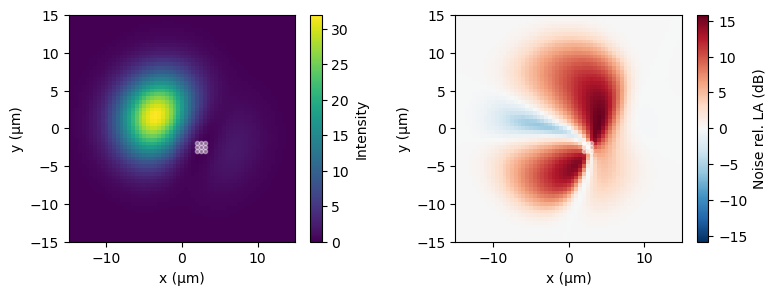

In [42]:
# Plot the output intensity noise relative to the intensity noise found by linear attenuation of the initial beam to the observed power 
# levels for the final optimization vectors
figure(figsize=(8,3))
subplot(121)
MultiModeNoise.plot_fiber(fiber["x"], reshape(n_x, (nx,nx)), 15, radius; cbarlabel="Intensity")
plot(vec(XX)[pixel_indices], vec(YY)[pixel_indices], "w.", alpha=0.4)
subplot(122)
MultiModeNoise.plot_fiber(fiber["x"], MultiModeNoise.lin_to_dB.(reshape(var_n_x_rel_LA, (nx,nx))), 15, radius; cmap="RdBu_r", 
    cbarlabel="Noise rel. LA (dB)", norm=mplcolors.CenteredNorm(vcenter=0))
plot(vec(XX)[pixel_indices], vec(YY)[pixel_indices], "w.", alpha=0.4)
tight_layout()

# Compute the intensity noise of randomly SLM patterns and combinations of output pixels
Here, we show how to compute the output intensity and intensity noise of a random collection of pixels for a random SLM pattern. This section contains all information to recreate Fig. 3c of the main manuscript. The input of the fiber is a Gaussian beam reflected of an SLM (possibly offset from the center) and then coupled into the fiber.

In [43]:
# We only randomly choose pixel inside an aperture of radius 20
apt_radius = 20
# Indices of the flattended array of x & y points inside the aperture
apt_inds = (1:nx^2)[vec(XX.^2 + YY.^2 .<= apt_radius.^2)]
# Number of pixels randomly chosen inside the aperture
n_pixels = 20
# Offset (in gridpoints) of the Gaussian beam on the SLM from the center
shift = 1
# Number of parameters in width and height used to parameterized the phase mask shown on the SLM
k_grid_width = 5
k_grid_height = 5
# Width (standard deviation) of the Gaussian laser beam [μm]
σ = 3.68;

In [44]:
# Random SLM parameters
fourier_coefs = randn(MersenneTwister(0), k_grid_height*k_grid_width);

In [45]:
# Spatial distribution of the Gaussian laser beam
beam = MultiModeNoise.gauss(XX, YY, σ);

In [46]:
# Conversion of the SLM parameters and laser to modal ampltidues at the input of the fiber
u0 = MultiModeNoise.fourier_coefs_to_u0(fourier_coefs, fiber, sim, k_grid_width, k_grid_height, beam; fourier_zoom=4, shift=shift);

In [47]:
# z-values at which to save u, μ, ν
fiber["zsave"] = [0, L_fiber];

In [48]:
# Solve for u, μ, ν
sol = MultiModeNoise.solve_cw_mmf(u0, fiber, sim)
uf = sol["uz"][end,:]
μf = sol["μz"][end,:,:]
νf = sol["νz"][end,:,:];

In [49]:
# Determine the random pixel combination of which we compute intensity and intensity noise.
pixel_collection_indices = shuffle(MersenneTwister(0), apt_inds)[1:n_pixels];

In [50]:
# Compute spatial itensity and intensity noise
n_xy, var_n_xy = MultiModeNoise.compute_cw_spatial_n_var_n(u0, uf, μf, νf, δF_in, fiber["phi"], P);

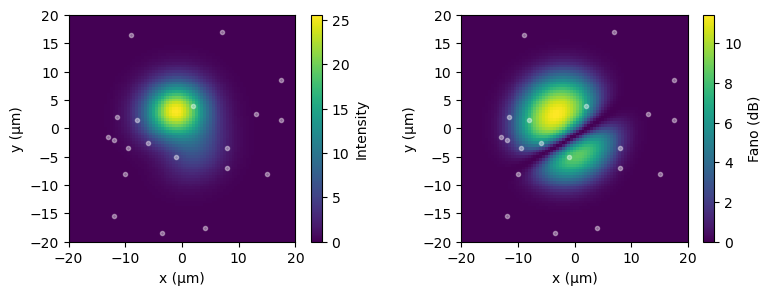

In [51]:
# Plot the spatial distribution of the output intensity and intensity noise. The locations of the random pixels are marked with white circles
figure(figsize=(8,3))
subplot(121)
MultiModeNoise.plot_fiber(fiber["x"], reshape(n_xy, (nx,nx)), apt_radius, radius; cbarlabel="Intensity")
plot(vec(XX)[pixel_collection_indices], vec(YY)[pixel_collection_indices], "w.", alpha=0.4)
subplot(122)
MultiModeNoise.plot_fiber(fiber["x"], MultiModeNoise.lin_to_dB.(reshape(var_n_xy ./ n_xy, (nx,nx))), apt_radius, radius; 
    cbarlabel="Fano (dB)")
plot(vec(XX)[pixel_collection_indices], vec(YY)[pixel_collection_indices], "w.", alpha=0.4)
tight_layout()

In [52]:
# Compute the intensity and intensity noise of the collection of random pixels
n, var_n = MultiModeNoise.compute_cw_superpixel_n_var_n(u0, uf, μf, νf, pixel_collection_indices, δF_in, fiber["phi"], P);

In [53]:
MultiModeNoise.lin_to_dB.(var_n / n)

6.563020839568209

In [54]:
using Tullio

In [59]:
"""
    compute_cw_pixel_pair_cov(u0, uf, μf, νf, pixel_collection_indices, fiber, sim)

Computes for a particular collection of pixels (given by their indices) the covariance matrix.
This function becomes very slow and memory-intensive for a large number of pixels, so use with caution.

# Arguments
- `u0`: Input modal amplitudes
- `uf`: Output modal amplitudes
- `μf`: Output Boboliubov coefficents
- `νf`: Output Boboliubov coefficents
- `pixel_collection_indices`: indices of the pixels for which to compute the covariance matrix
- `fiber`: Fiber parameter dictionary
- `sim`: Simulation parameter dictionary

# Outputs
- `Cov_n`: The intensity covariance matrix between pairs of pixels
"""
function compute_cw_pixel_pair_cov(u0, uf, μf, νf, pixel_collection_indices, fiber, sim)
    M = sim["M"]
    P = sim["P"]
    δF_in = sim["dF_in"]
    ϕ = fiber["phi"]
    
    U = u0/√P
    C0 = [[zeros(M,M) I(M) + 0.5*δF_in*U*U']; [0.5*δF_in*conj.(U)*transpose(U) zeros(M,M)]]
    J = [[μf νf]; [conj.(νf) conj.(μf)]]
    Cf = J * C0 * transpose(J)

    δuδu = Cf[1:M,1:M]
    δucδuc = Cf[M+1:2*M,M+1:2*M]
    δuδuc = Cf[1:M,M+1:2*M]
    δucδu = Cf[M+1:2*M,1:M]
    Δδuδuc = δuδuc - diagm(ones(M))

    ϕ_pixels = ϕ[pixel_collection_indices,:]
    α_pixels = ϕ_pixels * uf

    #transforming eigen to spatial correlation functions through basis functions ϕ
    @tullio δaδac[i,j] := ϕ_pixels[i,l] * conj(ϕ_pixels[j,k]) * Δδuδuc[l,k]
    @tullio δacδa[i,j] := conj(ϕ_pixels[i,l]) * ϕ_pixels[j,k] * δucδu[l,k]
    @tullio δaδa[i,j] := ϕ_pixels[i,l] * ϕ_pixels[j,k] * δuδu[l,k]
    @tullio δacδac[i,j] := conj(ϕ_pixels[i,l] * ϕ_pixels[j,k]) * δucδuc[l,k]

    @tullio intensity_terms[i,j] := conj(α_pixels[i]) * α_pixels[j] * δaδac[i,j] + α_pixels[i] * conj(α_pixels[j]) * δacδa[i,j]
    @tullio phase_terms[i,j] := conj(α_pixels[i]) * conj(α_pixels[j]) * δaδa[i,j] + α_pixels[i] * α_pixels[j] * δacδac[i,j]
    
    Cov_n = diagm(abs2.(α_pixels)) + intensity_terms + phase_terms
    
    return real.(Cov_n)
end

compute_cw_pixel_pair_cov

In [60]:
# Compute for the pixel collection the covariance matrix
Cov_n = compute_cw_pixel_pair_cov(u0, uf, μf, νf, pixel_collection_indices, fiber, sim);

In [61]:
MultiModeNoise.lin_to_dB(sum(Cov_n) / n)

6.563020839568884

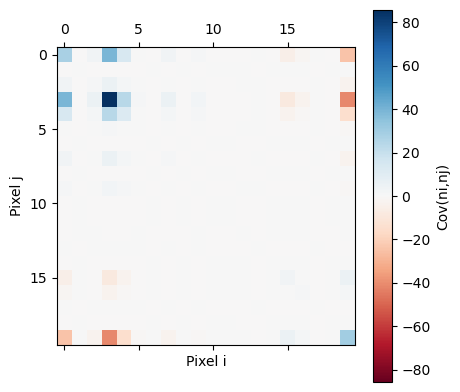

PyObject Text(24.0, 0.5, 'Pixel j')

In [62]:
matshow(Cov_n, norm=mplcolors.CenteredNorm(vcenter=0), cmap="RdBu")
colorbar(label="Cov(ni,nj)")
xlabel("Pixel i")
ylabel("Pixel j")